In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Employee_Attrition_Dataset_80_Records.csv')
df.head()

,EmpID,Age,Department,JobRole,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,Reason
0,1001,34,Admin,Manager,4,1,1,4,2,2,No,No,NaN
1,1002,22,Finance,Executive,11,5,5,1,3,2,No,No,NaN
2,1003,35,R&D,Supervisor,3,1,3,4,3,4,Yes,No,NaN
3,1004,22,Admin,Developer,9,5,3,2,2,1,Yes,No,NaN
4,1005,25,R&D,Officer,9,2,4,5,5,5,No,No,NaN


In [3]:
df.isnull().sum()

EmpID                      0
Age                        0
Department                 0
JobRole                    0
YearsAtCompany             0
JobSatisfaction            0
WorkLifeBalance            0
SalarySatisfaction         0
PromotionOpportunities     0
StressLevel                0
LookingForJob              0
WillLeave                  0
Reason                    65
dtype: int64

In [4]:
df = df.drop('Reason',axis=1)
df.head()

,EmpID,Age,Department,JobRole,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave
0,1001,34,Admin,Manager,4,1,1,4,2,2,No,No
1,1002,22,Finance,Executive,11,5,5,1,3,2,No,No
2,1003,35,R&D,Supervisor,3,1,3,4,3,4,Yes,No
3,1004,22,Admin,Developer,9,5,3,2,2,1,Yes,No
4,1005,25,R&D,Officer,9,2,4,5,5,5,No,No


In [5]:
df.describe()

,EmpID,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel
count,80.0000,80.000000,80.000000,80.000000,80.00000,80.000000,80.000000,80.000000
mean,1040.5000,34.987500,7.275000,2.850000,2.78750,2.712500,2.762500,2.825000
std,23.2379,8.171413,3.738188,1.397104,1.51527,1.424858,1.425303,1.421133
min,1001.0000,22.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000
25%,1020.7500,27.750000,4.000000,2.000000,1.00000,2.000000,1.000000,2.000000
50%,1040.5000,34.000000,7.500000,3.000000,2.00000,2.000000,3.000000,2.500000
75%,1060.2500,40.000000,10.000000,4.000000,4.00000,4.000000,4.000000,4.000000
max,1080.0000,50.000000,15.000000,5.000000,5.00000,5.000000,5.000000,5.000000


In [6]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first')

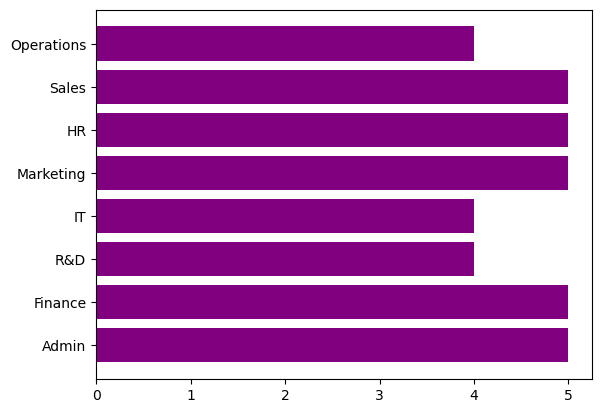

In [7]:
plt.barh(df.Department,df.JobSatisfaction,color='purple')
plt.show()

In [8]:
df.groupby('Department')['JobSatisfaction'].mean().reset_index()

,Department,JobSatisfaction
0,Admin,3.250000
1,Finance,3.300000
2,HR,3.000000
3,IT,2.923077
4,Marketing,3.333333
5,Operations,2.375000
6,R&D,1.818182
7,Sales,2.714286


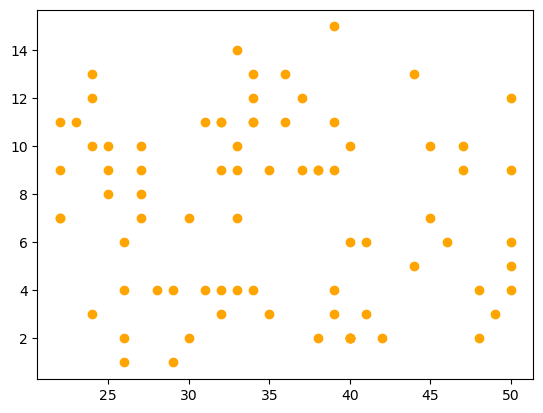

In [9]:
plt.scatter(df.Age,df.YearsAtCompany,color='orange')
plt.show()

In [10]:
print(round(df.JobSatisfaction.corr(df.StressLevel),2))
print(round(df.SalarySatisfaction.corr(df.StressLevel),2))
print(round(df.SalarySatisfaction.corr(df.StressLevel),2))
print(round(df.PromotionOpportunities.corr(df.Age),2))

-0.05
-0.09
-0.09
-0.2


In [11]:
df2=pd.get_dummies(data=df,columns=['Department','JobRole'],drop_first = True,dtype=int)
df2.head(10)

,EmpID,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,...,Department_Operations,Department_R&D,Department_Sales,JobRole_Developer,JobRole_Engineer,JobRole_Executive,JobRole_Manager,JobRole_Officer,JobRole_Scientist,JobRole_Supervisor
0,1001,34,4,1,1,4,2,2,No,No,...,0,0,0,0,0,0,1,0,0,0
1,1002,22,11,5,5,1,3,2,No,No,...,0,0,0,0,0,1,0,0,0,0
2,1003,35,3,1,3,4,3,4,Yes,No,...,0,1,0,0,0,0,0,0,0,1
3,1004,22,9,5,3,2,2,1,Yes,No,...,0,0,0,1,0,0,0,0,0,0
4,1005,25,9,2,4,5,5,5,No,No,...,0,1,0,0,0,0,0,1,0,0
5,1006,36,13,4,2,2,3,3,Yes,Yes,...,0,0,0,0,0,0,0,0,0,1
6,1007,40,2,1,5,3,1,2,Yes,Yes,...,0,1,0,1,0,0,0,0,0,0
7,1008,38,2,3,1,4,3,4,Yes,No,...,0,0,0,1,0,0,0,0,0,0
8,1009,33,10,2,3,3,1,4,No,No,...,0,0,0,0,0,1,0,0,0,0
9,1010,24,10,1,1,4,1,1,No,No,...,0,1,0,0,0,0,1,0,0,0


In [12]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [13]:
df2['LookingForJob']=le.fit_transform(df2['LookingForJob'])
df2['WillLeave']=le.fit_transform(df2['WillLeave'])

In [14]:
df2.head()

,EmpID,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,...,Department_Operations,Department_R&D,Department_Sales,JobRole_Developer,JobRole_Engineer,JobRole_Executive,JobRole_Manager,JobRole_Officer,JobRole_Scientist,JobRole_Supervisor
0,1001,34,4,1,1,4,2,2,0,0,...,0,0,0,0,0,0,1,0,0,0
1,1002,22,11,5,5,1,3,2,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1003,35,3,1,3,4,3,4,1,0,...,0,1,0,0,0,0,0,0,0,1
3,1004,22,9,5,3,2,2,1,1,0,...,0,0,0,1,0,0,0,0,0,0
4,1005,25,9,2,4,5,5,5,0,0,...,0,1,0,0,0,0,0,1,0,0


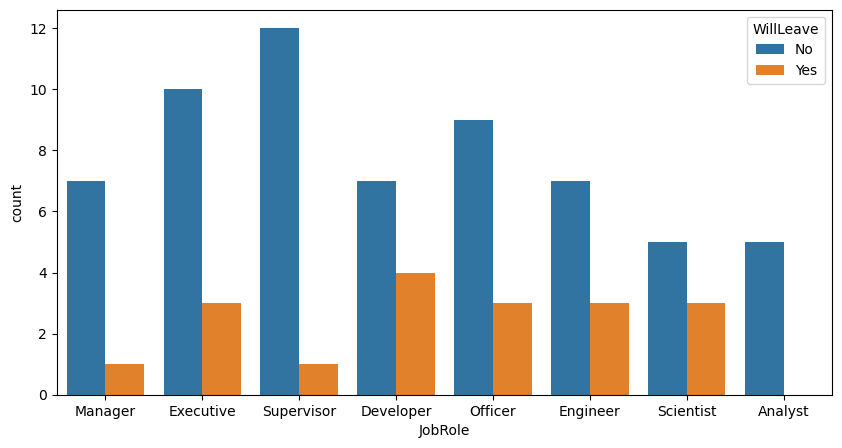

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="JobRole",hue="WillLeave")
plt.show()

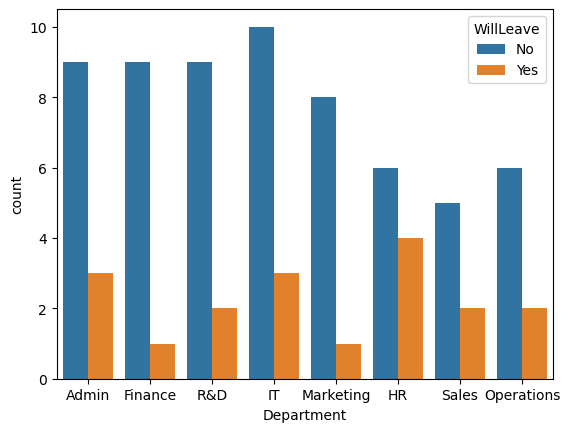

In [16]:
sns.countplot(data=df,x="Department",hue="WillLeave")
plt.show()

In [17]:
df2 = df2.drop('EmpID',axis=1)

In [18]:
df2

,Age,YearsAtCompany,JobSatisfaction,WorkLifeBalance,SalarySatisfaction,PromotionOpportunities,StressLevel,LookingForJob,WillLeave,Department_Finance,...,Department_Operations,Department_R&D,Department_Sales,JobRole_Developer,JobRole_Engineer,JobRole_Executive,JobRole_Manager,JobRole_Officer,JobRole_Scientist,JobRole_Supervisor
0,34,4,1,1,4,2,2,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,22,11,5,5,1,3,2,0,0,1,...,0,0,0,0,0,1,0,0,0,0
2,35,3,1,3,4,3,4,1,0,0,...,0,1,0,0,0,0,0,0,0,1
3,22,9,5,3,2,2,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0
4,25,9,2,4,5,5,5,0,0,0,...,0,1,0,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,38,9,2,2,5,5,2,1,0,0,...,1,0,0,0,0,0,0,0,0,0
76,22,7,4,2,1,2,2,0,0,0,...,0,0,0,0,0,0,0,1,0,0
77,36,11,4,5,3,3,4,0,0,0,...,0,0,0,0,0,0,0,0,0,1
78,33,9,2,1,5,3,2,1,1,0,...,0,0,0,1,0,0,0,0,0,0


In [19]:
x = df2.drop('WillLeave',axis=1)
y = df2['WillLeave']

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
lr = LogisticRegression()

In [21]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

In [22]:
lr.fit(x_train,y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
pred = lr.predict(x_test)

In [24]:
pred.shape

(20,)

In [25]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report,auc,pair_confusion_matrix,confusion_matrix

In [26]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        18
           1       0.50      0.50      0.50         2

    accuracy                           0.90        20
   macro avg       0.72      0.72      0.72        20
weighted avg       0.90      0.90      0.90        20



In [27]:
accuracy_score(y_test,pred)

0.9

In [28]:
precision_score(y_test,pred)

0.5

In [29]:
recall_score(y_test,pred)

0.5

In [30]:
cm=confusion_matrix(y_test,pred)
cm

array([[17,  1],
       [ 1,  1]])

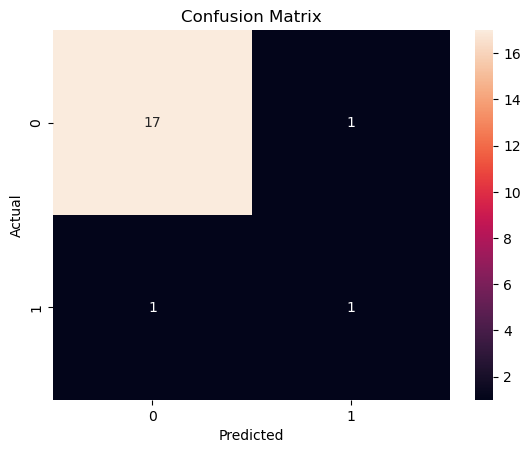

In [31]:
sns.heatmap(cm,annot=True,fmt='d',cmap='rocket')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [32]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [33]:
pred1=dt.predict(x_test)

In [34]:
accuracy_score(y_test,pred1)

0.95

In [35]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier()
rf.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
pred2=rf.predict(x_test)
pred2

array([0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [40]:
recall_score(y_test,pred2)

0.0

In [38]:
print(classification_report(y_test,pred2))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92        18
           1       0.00      0.00      0.00         2

    accuracy                           0.85        20
   macro avg       0.45      0.47      0.46        20
weighted avg       0.81      0.85      0.83        20



In [39]:
precision_score(y_test,pred2)

0.0

In [45]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


In [49]:
import shap
explainer = shap.Explainer(lr,x_train)
shap_values = explainer(x_test)

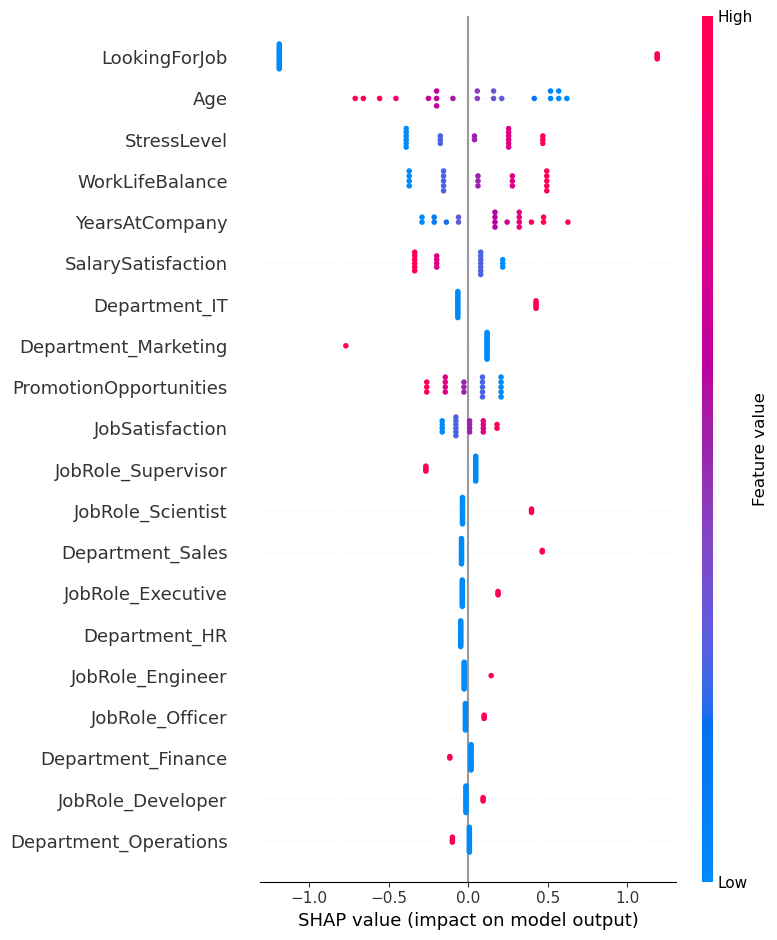

In [51]:
shap.summary_plot(shap_values,x_test)

In [54]:
!pip install lifelines

Defaulting to user installation because normal site-packages is not writeable


In [57]:
from lifelines import CoxPHFitter

In [59]:
cph = CoxPHFitter()
cph.fit(df2,duration_col = 'JobSatisfaction',
        event_col = 'WillLeave')
cph.print_summary()

C:\Users\BISHAK\AppData\Roaming\Python\Python313\site-packages\lifelines\utils\__init__.py:1120: ConvergenceWarning: Column LookingForJob have very low variance when conditioned on death event present or not. This may harm convergence. This could be a form of 'complete separation'. For example, try the following code:

>>> events = df['WillLeave'].astype(bool)
>>> print(df.loc[events, 'LookingForJob'].var())
>>> print(df.loc[~events, 'LookingForJob'].var())

A very low variance means that the column LookingForJob completely determines whether a subject dies or not. See https://stats.stackexchange.com/questions/11109/how-to-deal-with-perfect-separation-in-logistic-regression.

  warnings.warn(dedent(warning_text), ConvergenceWarning)
C:\Users\BISHAK\AppData\Roaming\Python\Python313\site-packages\lifelines\fitters\coxph_fitter.py:1607: ConvergenceWarning: Newton-Raphson convergence completed successfully but norm(delta) is still high, 1.032. This may imply non-unique solutions to the max

<lifelines.CoxPHFitter: fitted with 80 total observations, 62 right-censored observations>
             duration col = 'JobSatisfaction'
                event col = 'WillLeave'
      baseline estimation = breslow
   number of observations = 80
number of events observed = 18
   partial log-likelihood = -29.39
         time fit was run = 2026-01-19 15:04:16 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
Age                    -0.03      0.97      0.08           -0.19            0.13                0.82                1.14
YearsAtCompany          0.04      1.04      0.12           -0.19            0.28                0.82                1.32
WorkLifeBalance         0.86      2.37      0.39            0.09            1.63                1.10                5.11
SalarySatisfaction     -0.87      0.42      0.64           -2.13            0.38                0.12                1.46
PromotionOpportunities  0.25      1.28      0.54           -0.80            1.30                0.45                3.67
StressLevel             0.39      1.48      0.42           -0.42            1.21                0.66                3.34
LookingForJob          26.11  2.19e+11   3556.44        -6944.38         6996.61                0.00                 inf
Department_Finance      0.02      1.02      2.66           -5.19            5.22                0.01              185.57
Department_HR           4.33     76.00      1.76            0.89            7.77                2.43             2376.38
Department_IT           6.86    951.65      2.15            2.64           11.08               14.03            64564.38
Department_Marketing   -1.06      0.34      1.40           -3.81            1.68                0.02                5.38
Department_Operations   4.63    102.69      2.00            0.72            8.55                2.05             5145.33
Department_R&D          6.85    945.19      2.19            2.55           11.15               12.86            69474.62
Department_Sales        4.50     90.00      2.20            0.19            8.81                1.21             6673.20
JobRole_Developer      18.38  9.63e+07  13045.09       -25549.52        25586.28                0.00                 inf
JobRole_Engineer       16.61  1.64e+07  13045.09       -25551.28        25584.51                0.00                 inf
JobRole_Executive      13.43  6.80e+05  13045.09       -25554.47        25581.33                0.00                 inf
JobRole_Manager        18.50  1.09e+08  13045.09       -25549.39        25586.40                0.00                 inf
JobRole_Officer        19.78  3.91e+08  13045.09       -25548.11        25587.68                0.00                 inf
JobRole_Scientist      19.85  4.18e+08  13045.09       -25548.05        25587.75                0.00                 inf
JobRole_Supervisor     19.37  2.58e+08  13045.09       -25548.53        25587.27                0.00                 inf

                        cmp to     z      p  -log2(p)
covariate                                            
Age                       0.00 -0.38   0.71      0.50
YearsAtCompany            0.00  0.36   0.72      0.47
WorkLifeBalance           0.00  2.20   0.03      5.16
SalarySatisfaction        0.00 -1.37   0.17      2.54
PromotionOpportunities    0.00  0.47   0.64      0.64
StressLevel               0.00  0.94   0.34      1.54
LookingForJob             0.00  0.01   0.99      0.01
Department_Finance        0.00  0.01   1.00      0.01
Department_HR             0.00  2.47   0.01      6.19
Department_IT             0.00  3.19 <0.005      9.44
Department_Marketing      0.00 -0.76   0.45      1.16
Department_Operations     0.00  2.32   0.02      5.62
Department_R&D            0.00  3.12 <0.005      9.13
Department_Sales          0.00  2.05   